# Ethics in Artificial Intelligence
## Module 5 — Overview Notebook

This notebook provides a tour of the key technical concepts in AI ethics:
1. Fairness metrics and bias detection
2. Explainability basics
3. Differential privacy
4. Social impact simulation

Run each cell to see the demonstrations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
print("All imports successful.")

All imports successful.


## 1. Fairness Metrics

We generate a synthetic dataset and compute standard fairness metrics across demographic groups.

In [2]:
def generate_dataset(n=2000):
    race = np.random.choice(['A', 'B'], size=n, p=[0.7, 0.3])
    income = np.where(race == 'A',
                      np.random.normal(70, 20, n),
                      np.random.normal(50, 15, n))
    score = np.where(race == 'A',
                     np.random.normal(700, 50, n),
                     np.random.normal(650, 60, n))
    default = np.random.binomial(1, 0.1 + 0.3 * (score < 650).astype(int))
    return pd.DataFrame({'race': race, 'income': income, 'score': score, 'default': default})

df = generate_dataset()
print("Base rate by group:")
print(df.groupby('race')['default'].mean().round(3))

Base rate by group:
race
A    0.144
B    0.272
Name: default, dtype: float64


In [3]:
def fairness_audit(y_true, y_pred, protected):
    groups = np.unique(protected)
    for g in groups:
        mask = protected == g
        yt, yp = y_true[mask], y_pred[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        approval = yp.mean()
        print(f"Group {g}: TPR={tpr:.3f}, FPR={fpr:.3f}, Approval={approval:.3f}")

X = df[['income', 'score']]
y = df['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

protected = df.iloc[X_test.index]['race'].values
print("Fairness Audit:")
fairness_audit(y_test.values, y_pred, protected)

diff = (y_pred[protected == 'A'].mean() - y_pred[protected == 'B'].mean())
print(f"\nDemographic Parity Difference: {diff:.4f}")

Fairness Audit:
Group A: TPR=0.000, FPR=0.003, Approval=0.002
Group B: TPR=0.093, FPR=0.047, Approval=0.060

Demographic Parity Difference: -0.0577


## 2. Explainability

We inspect model coefficients for an interpretable model.

In [4]:
coef_df = pd.DataFrame({
    'feature': ['income', 'score'],
    'coefficient': model.coef_[0]
})
print("Model Coefficients (interpretable explanation):")
print(coef_df)
print("\nPositive coefficient = increases default probability.")

Model Coefficients (interpretable explanation):
  feature  coefficient
0  income    -0.000209
1   score    -0.013085

Positive coefficient = increases default probability.


## 3. Differential Privacy

We implement the Laplace mechanism for releasing the mean of a dataset with formal privacy guarantees.

In [5]:
def laplace_mechanism(true_value, sensitivity, epsilon):
    noise = np.random.laplace(0, sensitivity / epsilon)
    return true_value + noise

data = np.random.normal(50, 15, 1000)
true_mean = np.mean(data)

epsilons = [0.01, 0.1, 1, 10]
print(f"True mean: {true_mean:.2f}")
for eps in epsilons:
    private = laplace_mechanism(true_mean, (data.max() - data.min()) / len(data), eps)
    print(f"  epsilon={eps:.2f}: private mean={private:.2f} (error={abs(private-true_mean):.2f})")

True mean: 50.18
  epsilon=0.01: private mean=64.89 (error=14.71)
  epsilon=0.10: private mean=49.69 (error=0.49)
  epsilon=1.00: private mean=50.23 (error=0.05)
  epsilon=10.00: private mean=50.19 (error=0.01)


## 4. Social Impact: Carbon Footprint Comparison

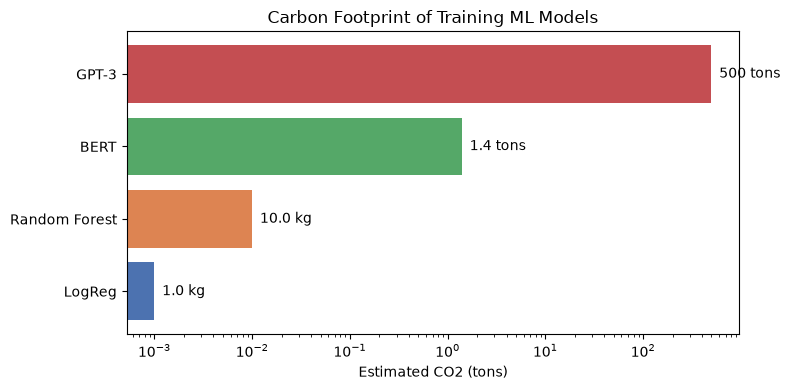

In [6]:
models = ['LogReg', 'Random Forest', 'BERT', 'GPT-3']
co2_estimates = [0.001, 0.01, 1.4, 500]

plt.figure(figsize=(8, 4))
plt.barh(models, co2_estimates, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.xlabel('Estimated CO2 (tons)')
plt.xscale('log')
plt.title('Carbon Footprint of Training ML Models')
for i, v in enumerate(co2_estimates):
    plt.text(v * 1.2, i, f'{v} tons' if v > 0.1 else f'{v*1000} kg', va='center')
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated four key technical areas of AI ethics:
1. **Fairness metrics**: Detecting demographic disparities in model predictions
2. **Explainability**: Understanding what features drive model decisions
3. **Differential privacy**: Protecting individual data in aggregate statistics
4. **Environmental impact**: The carbon cost of different ML models

Each of these areas is explored in depth in the lesson notebooks.